In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/Lotus Balancing & Hydrating Natural Face Treatment Oil Reviews:Rating.csv.crdownload.csv")
df

,rating,review_text
0,5,I absolutely L-O-V-E this oil. I have acne pro...
1,3,I gave this 3 stars because it give me tiny li...
2,5,Works well as soon as I wash my face and pat d...
3,5,"this oil helped with hydration and breakouts, ..."
4,5,This is my first product review ever so that s...
...,...,...
49972,5,Consider salicylic acid your secret weapon for...
49973,5,I’ve been using this as my only moisturizer fo...
49974,5,I got breakouts whenever it’s my time of month...
49975,5,I love this!!! I don’t get actual acne just an...


In [3]:
df.isna().sum()

rating          0
review_text    59
dtype: int64

In [4]:
df_clean = df.dropna()

In [5]:
X = df_clean["review_text"]
y = df_clean["rating"]

In [6]:
X.isna().sum()

0

In [17]:
import re
import pandas as pd 
import nltk
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize 
from nltk.stem import PorterStemmer 
from nltk.stem.wordnet import WordNetLemmatizer
import re
from sklearn.model_selection import train_test_split
import pickle

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def preprocess_text(input_text, use_stemming=True, use_lemmatization=True):

    if not isinstance(input_text, str):
        input_text = str(input_text)

    # Convert to lowercase
    preprocessed_text = input_text.lower ()

    # Remove punctuation
    preprocessed_text = re.sub(r'[^\w\s]', '', preprocessed_text)
                               
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    stop_words.remove("not")
    word_tokens = word_tokenize(preprocessed_text)
    filtered_words = [word for word in word_tokens if word not in stop_words]

    # Initialize stemmer and lemmatizer
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    
    # Optionally apply stemming and lemmatization
    if use_stemming:
        filtered_words = [stemmer.stem(word) for word in filtered_words]
    if use_lemmatization:
        filtered_words = [lemmatizer.lemmatize(word) for word in filtered_words]
    
    preprocessed_text = ' '.join(filtered_words)
    
    return preprocessed_text

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pearly/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pearly/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/pearly/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/pearly/nltk_data...


In [18]:
X_preprocessed = [ preprocess_text(text) for text in X ]

In [19]:
X_preprocessed[:5]

['absolut love oil acn prone skin 30 use top even cream final moistur lockin smell spagrad aromatherapi treatment instantli relax ive facial oil routin previous drunk eleph year swear wrinkl prevent qualiti oilyacn prone skin becom dri acidstreat use import put moistur back taken prevent skin overcompens throughout day formula lotu keep breakout peski wrinkl away scent oil look forward everi even final pamper doesnt break skin glow applic one bottl last least 6 month drop need cover face neck décolleté your fenc treat',
 'gave 3 star give tini littl white head first use ima give day make final decis keep return thought keep oili face control not oili feel though trap oil pore',
 'work well soon wash face pat dri smell amaz',
 'oil help hydrat breakout love',
 'first product review ever tell much love actual bought low 20 drink eat terribl food use strongaggress product colleg one oil much year later understand sensit acnepron skin great skincar routin decid give tri oh gosh maskn disap

In [30]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check the shape of the resulting data
X_train.shape, X_test.shape

((39934,), (9984,))

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

# Fit and transform X_train
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

In [32]:
X_train_vectors

<39934x21046 sparse matrix of type '<class 'numpy.int64'>'
	with 1730398 stored elements in Compressed Sparse Row format>

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_vectors,y_train)

/Users/pearly/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [37]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vectors)
accuracy = accuracy_score(y_test, y_pred)

print(f'Validation Accuracy: {accuracy * 100:.2f}%')

Validation Accuracy: 63.62%


In [38]:
with open("../Output/vectorizer.pkl", 'wb') as file:
    pickle.dump(vectorizer, file)

with open("../Output/model.pkl", 'wb') as file:
    pickle.dump(model,file)
print("Model saved successfully")

Model saved successfully


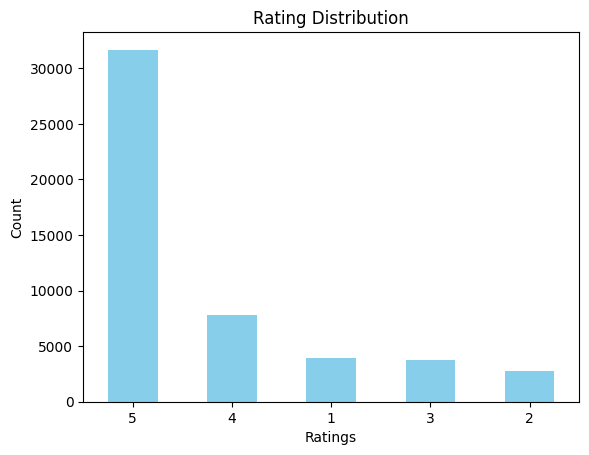

In [29]:
import matplotlib.pyplot as plt

# Check class distribution
rating_counts = df_clean['rating'].value_counts()
rating_counts.plot(kind='bar', color='skyblue')
plt.title('Rating Distribution')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
